# POD-NN for Parametric Navier-Stokes

**MODEL ORDER REDUCTION AND MACHINE LEARNING - Project**  
**A.Y. 2025/2026**

This notebook applies the **POD-NN** strategy to the parametric Navier-Stokes problem.

The idea: instead of solving a reduced system online (which for non-linear, non-affine problems still requires FOM-level assembly), we train a feedforward neural network to **directly predict the reduced coordinates** $\underline{u}_{\mathsf{rb}}(\boldsymbol\mu)$ given a new parameter $\boldsymbol\mu$.

The online phase then costs only a NN forward pass + a matrix-vector product — **no linear solve, no FOM assembly**.

---

## Problem

Solve the Navier-Stokes equation on $\Omega = (0,1)^2$:

$$
\begin{cases}
-\mu_0 \nabla \cdot (\nabla \mathbf{u}) + (\nabla \mathbf{u})\mathbf{u} + \nabla p = \mathbf{f}(x;\mu_1) & \text{in } \Omega\\
\nabla \cdot \mathbf{u} = 0 & \text{in } \Omega\\
\mathbf{u} = 0 & \text{on } \partial\Omega
\end{cases}
$$

with $\boldsymbol\mu = (\mu_0, \mu_1) \in [0.1, 10] \times [1.0, 3.0]$.

## Part 0 — Setup

In [2]:
import numpy as np
import argparse
import os.path
import scipy.sparse
import vtk
from pypolydim import polydim, gedim
from pypolydim.export_vtk_utilities import ExportVTKUtilities
from pypolydim.assembler_utilities import assembler_utilities
import matplotlib.pyplot as plt
import time

import sys
sys.path.insert(1, '../')
import other_utilities as other_ut

In [3]:
geometry_utilities_config = gedim.GeometryUtilitiesConfig()
geometry_utilities_config.tolerance1_d = 1.0e-6
geometry_utilities_config.tolerance2_d = 1.0e-12
geometry_utilities = gedim.GeometryUtilities(geometry_utilities_config)
mesh_utilities = gedim.MeshUtilities()
vtk_utilities = ExportVTKUtilities()

In [4]:
# Export folder
export_file_path = "./Export/POD_NN"
if not os.path.exists(export_file_path):
    os.makedirs(export_file_path)
export_solution_path = export_file_path + "/Solution"
if not os.path.exists(export_solution_path):
    os.makedirs(export_solution_path)

## Part 1 — Mesh and Finite Element Space

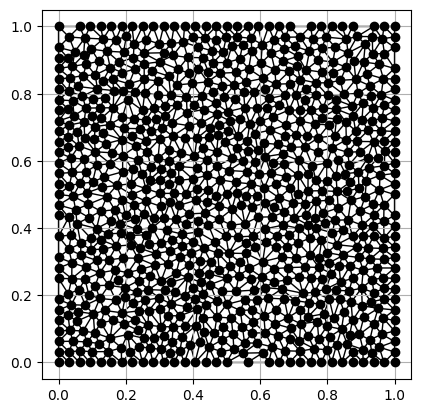

In [5]:
# Defining the unit square domain.
pde_domain = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D()
pde_domain.vertices = np.array([[0.0, 1.0, 1.0, 0.0],
                                [0.0, 0.0, 1.0, 1.0],
                                [0.0, 0.0, 0.0, 0.0]])
pde_domain.shape_type = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D.Domain_Shape_Types.parallelogram
pde_domain.area = 1.0

mesh_type = polydim.pde_tools.mesh.pde_mesh_utilities.MeshGenerator_Types_2D.triangular
method_type = polydim.pde_tools.local_space_pcc_2_d.MethodTypes.fem_pcc
mesh_size = 0.001

mesh_data = gedim.MeshMatrices()
mesh = gedim.MeshMatricesDAO(mesh_data)

polydim.pde_tools.mesh.pde_mesh_utilities.create_mesh_2_d(geometry_utilities,
                                                          mesh_utilities,
                                                          mesh_type,
                                                          pde_domain,
                                                          mesh_size,
                                                          mesh)
mesh_geometric_data = polydim.pde_tools.mesh.pde_mesh_utilities.compute_mesh_2_d_geometry_data(
    geometry_utilities, mesh_utilities, mesh)

vtk_utilities.export_mesh(export_file_path, mesh)
other_ut.plot_mesh(mesh)

In [6]:
# Boundary conditions: u=0 on all borders, p=0 at point (0,0).
info_internal = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(
    polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_internal.marker = 0

info_dirichlet = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(
    polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.strong)
info_dirichlet.marker = 1

info_neumann_none = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(
    polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_neumann_none.marker = 0

pressure_boundary_info = {
    0: info_internal, 1: info_dirichlet,
    2: info_neumann_none, 3: info_neumann_none, 4: info_neumann_none,
    5: info_neumann_none, 6: info_neumann_none, 7: info_neumann_none, 8: info_neumann_none
}

speed_boundary_info = {
    0: info_internal,
    1: info_dirichlet, 2: info_dirichlet, 3: info_dirichlet, 4: info_dirichlet,
    5: info_dirichlet, 6: info_dirichlet, 7: info_dirichlet, 8: info_dirichlet
}

# Taylor-Hood P2/P1 element.
mesh_connectivity_data = polydim.pde_tools.mesh.MeshMatricesDAO_mesh_connectivity_data(mesh)

pressure_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, 1)
speed_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, 2)

dof_manager = polydim.pde_tools.do_fs.DOFsManager()

pressure_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(
    pressure_reference_element_data, mesh, pressure_boundary_info)
pressure_dofs_data = dof_manager.create_do_fs_2_d(pressure_mesh_dofs_info, mesh_connectivity_data)

speed_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(
    speed_reference_element_data, mesh, speed_boundary_info)
speed_dofs_data = dof_manager.create_do_fs_2_d(speed_mesh_dofs_info, mesh_connectivity_data)

pressure_n_dofs = pressure_dofs_data.number_do_fs
pressure_n_strongs = pressure_dofs_data.number_strongs
speed_n_dofs = speed_dofs_data.number_do_fs
speed_n_strongs = speed_dofs_data.number_strongs
tot_dofs = 2 * speed_n_dofs + pressure_n_dofs
tot_strongs = 2 * speed_n_strongs + pressure_n_strongs

print("P dofs\t", "P stgs\t", "U dofs\t", "U stgs\t", "T dofs\t", "T stgs")
print(pressure_n_dofs, "\t", pressure_n_strongs, "\t",
      speed_n_dofs, "\t", speed_n_strongs, "\t", tot_dofs, "\t", tot_strongs)

P dofs	 P stgs	 U dofs	 U stgs	 T dofs	 T stgs
829 	 1 	 2966 	 234 	 6761 	 469


## Part 2 — FOM Solver (Newton's Method)

The source term $\mathbf{f}(x;\mu_1)$ depends on $\mu_1$ non-affinely, so the full FOM assembly is required for each snapshot. We encapsulate this in `solve_ns`.

In [7]:
def f_x_function(x, y, z, mu):
    """x-component of the body force (depends on mu_1)."""
    term1 = -(mu[1]**3 * np.pi**2 * np.cos(mu[1]**2 * np.pi * x)
              - mu[1]**2 * np.pi**2) \
             * np.sin(mu[1] * np.pi * y) * np.cos(mu[1] * np.pi * y)
    term2 = mu[1] * np.pi * np.cos(mu[1] * np.pi * x) * np.cos(mu[1] * np.pi * y)
    return term1 + term2

def f_y_function(x, y, z):
    """y-component of the body force (zero)."""
    return np.zeros_like(x)

def pressure_strong_function(marker, x, y, z):
    return np.zeros_like(x)

def speed_x_strong_function(marker, x, y, z):
    return np.zeros_like(x)

def speed_y_strong_function(marker, x, y, z):
    return np.zeros_like(x)

def speed_x_initial_condition(x, y, z):
    return 0.0

def speed_y_initial_condition(x, y, z):
    return 0.0

def pressure_initial_condition(x, y, z):
    return 0.0

def b_x_term(x, y, z):
    return np.array([1.0, 0.0, 0.0])

def b_y_term(x, y, z):
    return np.array([0.0, 1.0, 0.0])

In [8]:
def solve_ns(mu, newton_tol=1.0e-6, max_iterations=10, verbose=False):
    """
    Full-order Navier-Stokes solver for a given mu = [mu_0, mu_1].
    """
    f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_reference_element_data, speed_reference_element_data,
        lambda x, y, z: f_x_function(x, y, z, mu))
    f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_reference_element_data, speed_reference_element_data,
        f_y_function)
    f_S = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])

    u_x_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_mesh_dofs_info, speed_dofs_data, speed_reference_element_data,
        speed_x_strong_function)
    u_y_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_mesh_dofs_info, speed_dofs_data, speed_reference_element_data,
        speed_y_strong_function)

    A_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_diffusion_operator(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_dofs_data,
        speed_reference_element_data, speed_reference_element_data,
        lambda x, y, z: mu[0])
    B_x_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, pressure_dofs_data,
        speed_reference_element_data, pressure_reference_element_data,
        b_x_term)
    B_y_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, pressure_dofs_data,
        speed_reference_element_data, pressure_reference_element_data,
        b_y_term)

    J_A_x   = other_ut.make_np_sparse(A_operator.operator_dofs,   [tot_dofs, tot_dofs], [0, 0])
    J_A_y   = other_ut.make_np_sparse(A_operator.operator_dofs,   [tot_dofs, tot_dofs], [speed_n_dofs, speed_n_dofs])
    J_B_x   = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2*speed_n_dofs, 0])
    J_B_y   = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2*speed_n_dofs, speed_n_dofs])
    J_BT_x  = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2*speed_n_dofs, 0], True)
    J_BT_y  = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2*speed_n_dofs, speed_n_dofs], True)
    J_S = J_A_x + J_A_y - J_B_x - J_B_y - J_BT_x - J_BT_y

    u_x_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_reference_element_data, speed_x_initial_condition).function_dofs
    u_y_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_reference_element_data, speed_y_initial_condition).function_dofs
    p_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(
        geometry_utilities, mesh, mesh_geometric_data,
        pressure_dofs_data, pressure_reference_element_data, pressure_initial_condition).function_dofs
    u_k = np.concatenate([u_x_numeric, u_y_numeric, p_numeric])

    du_x_strong = np.zeros(speed_n_strongs)
    du_y_strong = np.zeros(speed_n_strongs)
    dp_strong   = np.zeros(pressure_n_strongs)

    # Newton iterations.
    residual_norm = 1.0
    solution_norm = 1.0
    num_iteration = 1
    while num_iteration < max_iterations and residual_norm > newton_tol * solution_norm:
        c_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_ns_operators(
            geometry_utilities, mesh, mesh_geometric_data,
            speed_dofs_data, speed_reference_element_data,
            u_x_numeric, u_y_numeric, u_x_strong, u_y_strong)
        J_C = other_ut.make_np_sparse(c_operator.convective_operator.operator_dofs, [tot_dofs, tot_dofs], [0, 0])
        f_C = np.concatenate([c_operator.convective_rhs, np.zeros(pressure_n_dofs)])

        J_f = f_S - f_C - J_S @ u_k
        du  = scipy.sparse.linalg.spsolve(J_S + J_C, J_f)
        u_k = u_k + du

        du_x = du[0:speed_n_dofs]
        du_y = du[speed_n_dofs:2*speed_n_dofs]
        dp   = du[2*speed_n_dofs:]

        u_x_numeric = u_k[0:speed_n_dofs]
        u_y_numeric = u_k[speed_n_dofs:2*speed_n_dofs]
        p_numeric   = u_k[2*speed_n_dofs:]

        du_x_err = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities, mesh, mesh_geometric_data,
            speed_dofs_data, speed_reference_element_data, du_x, du_x_strong)
        du_y_err = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities, mesh, mesh_geometric_data,
            speed_dofs_data, speed_reference_element_data, du_y, du_y_strong)
        dp_err = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities, mesh, mesh_geometric_data,
            pressure_dofs_data, pressure_reference_element_data, dp, dp_strong)

        residual_norm = np.sqrt(
            du_x_err.numeric_norm_l2**2 + du_y_err.numeric_norm_l2**2 + dp_err.numeric_norm_l2**2)
        if verbose:
            print(f"  Newton iter {num_iteration}: residual = {residual_norm/solution_norm:.4e}")
        num_iteration += 1

    return u_k

## Part 3 — Offline Phase: Snapshot Collection and POD

We sample $N_s$ parameter instances from $\mathcal{P}$ and solve the FOM for each. The snapshot matrix is then processed via the covariance matrix eigendecomposition.

In [9]:
# Parameter space.
mu0_range = [0.1, 10.0]
mu1_range = [1.0, 3.0]
P = np.array([mu0_range, mu1_range])

snapshot_num = 200
np.random.seed(0)
training_set = np.random.uniform(low=P[:, 0], high=P[:, 1], size=(snapshot_num, P.shape[0]))

In [10]:
# Inner product matrices.
A_ref = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_diffusion_operator(
    geometry_utilities, mesh, mesh_geometric_data,
    speed_dofs_data, speed_dofs_data,
    speed_reference_element_data, speed_reference_element_data,
    lambda x, y, z: 1.0)
B_x_ref = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(
    geometry_utilities, mesh, mesh_geometric_data,
    speed_dofs_data, pressure_dofs_data,
    speed_reference_element_data, pressure_reference_element_data,
    b_x_term)
B_y_ref = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(
    geometry_utilities, mesh, mesh_geometric_data,
    speed_dofs_data, pressure_dofs_data,
    speed_reference_element_data, pressure_reference_element_data,
    b_y_term)

# H1 semi-norm inner product for velocity.
X_1 = other_ut.make_np_sparse(A_ref.operator_dofs, [2*speed_n_dofs, 2*speed_n_dofs], [0, 0])
X_2 = other_ut.make_np_sparse(A_ref.operator_dofs, [2*speed_n_dofs, 2*speed_n_dofs], [speed_n_dofs, speed_n_dofs])
inner_product_u = X_1 + X_2 

B_1 = other_ut.make_np_sparse(B_x_ref.operator_dofs, [pressure_n_dofs, 2*speed_n_dofs], [0, 0])
B_2 = other_ut.make_np_sparse(B_y_ref.operator_dofs, [pressure_n_dofs, 2*speed_n_dofs], [0, speed_n_dofs])

In [11]:
# Build snapshot matrices. For N-S with Taylor-Hood, we collect:
#   - velocity snapshots (u_x, u_y) 
#   - supremizer snapshots           
#   - pressure snapshots           

snapshot_matrix_u = []   
snapshot_matrix_s = []   
snapshot_matrix_p = []  

tol    = 1. - 1e-7
N_max  = 20

print("Collecting snapshots (FOM solves)...")
for it, mu in enumerate(training_set):
    if it % 10 == 0:
        print(f"  Snapshot {it}/{snapshot_num}  mu0={mu[0]:.3f}  mu1={mu[1]:.3f}")

    u_k = solve_ns(mu)

    snap_u = u_k[0:2*speed_n_dofs]
    snap_p = u_k[2*speed_n_dofs:]

    snap_s = scipy.sparse.linalg.spsolve(X_1 + X_2, np.transpose(B_1 + B_2) @ snap_p)

    snapshot_matrix_u.append(np.copy(snap_u))
    snapshot_matrix_s.append(np.copy(snap_s))
    snapshot_matrix_p.append(np.copy(snap_p))

snapshot_matrix_u = np.array(snapshot_matrix_u)
snapshot_matrix_s = np.array(snapshot_matrix_s)
snapshot_matrix_p = np.array(snapshot_matrix_p)
print("Snapshot collection complete.")
print(f"  snapshot_matrix_u: {snapshot_matrix_u.shape}")
print(f"  snapshot_matrix_s: {snapshot_matrix_s.shape}")
print(f"  snapshot_matrix_p: {snapshot_matrix_p.shape}")

  Snapshot 0/200  mu0=5.533  mu1=2.430
  Snapshot 10/200  mu0=9.788  mu1=2.598
  Snapshot 20/200  mu0=3.659  mu1=1.874
  Snapshot 30/200  mu0=1.674  mu1=1.221
  Snapshot 40/200  mu0=3.248  mu1=1.829
  Snapshot 50/200  mu0=6.810  mu1=1.540
  Snapshot 60/200  mu0=7.280  mu1=2.003
  Snapshot 70/200  mu0=8.976  mu1=1.735
  Snapshot 80/200  mu0=7.005  mu1=1.907
  Snapshot 90/200  mu0=1.730  mu1=2.243
  Snapshot 100/200  mu0=3.187  mu1=2.393
  Snapshot 110/200  mu0=6.327  mu1=2.745
  Snapshot 120/200  mu0=8.652  mu1=1.235
  Snapshot 130/200  mu0=2.484  mu1=1.201
  Snapshot 140/200  mu0=3.001  mu1=2.698
  Snapshot 150/200  mu0=9.075  mu1=2.548
  Snapshot 160/200  mu0=2.776  mu1=1.263
  Snapshot 170/200  mu0=3.771  mu1=1.394
  Snapshot 180/200  mu0=1.953  mu1=2.808
  Snapshot 190/200  mu0=8.591  mu1=1.914
Snapshot collection complete.
  snapshot_matrix_u: (200, 5932)
  snapshot_matrix_s: (200, 5932)
  snapshot_matrix_p: (200, 829)


In [12]:
def eig_analysis(C, N_max=None, tol=1e-9):
    '''Eigendecomposition of C with eigenvalues sorted in DESCENDING order.
    '''
    L_e, VM_e = np.linalg.eig(C)

    eigenvalues_raw = L_e.real
    eigenvectors_raw = VM_e.real   

    # Ssort by descending eigenvalue so mode 0 is the most energetic.
    sort_idx = np.argsort(eigenvalues_raw)[::-1]
    eigenvalues  = eigenvalues_raw[sort_idx].tolist()
    eigenvectors = [eigenvectors_raw[:, sort_idx[i]] for i in range(len(sort_idx))]

    total_energy = sum(eigenvalues)
    retained = np.cumsum(eigenvalues) / total_energy

    if N_max is not None and all(r < tol for r in retained):
        N = N_max
    else:
        N = int(np.argmax(retained >= tol)) + 1

    return N, eigenvectors, retained


def create_basis_functions_matrix(N, snapshot_matrix, eigenvectors, inner_product=None):
    '''Build X-orthonormal POD basis from snapshot matrix and eigenvectors.
    Each basis vector is  phi_n = S^T v_n / ||S^T v_n||_X
    where v_n is the n-th eigenvector of the covariance matrix C = S X S^T.
    '''
    basis_functions = []
    for n in range(N):
        basis = np.transpose(snapshot_matrix) @ eigenvectors[n]
        if inner_product is not None:
            norm = np.sqrt(np.transpose(basis) @ inner_product @ basis)
        else:
            norm = np.sqrt(np.dot(basis, basis))
        basis /= norm
        basis_functions.append(np.copy(basis))
    return np.transpose(np.array(basis_functions))


POD dimensions — N_u: 22,  N_s: 27,  N_p: 24
Total reduced dimension: 73


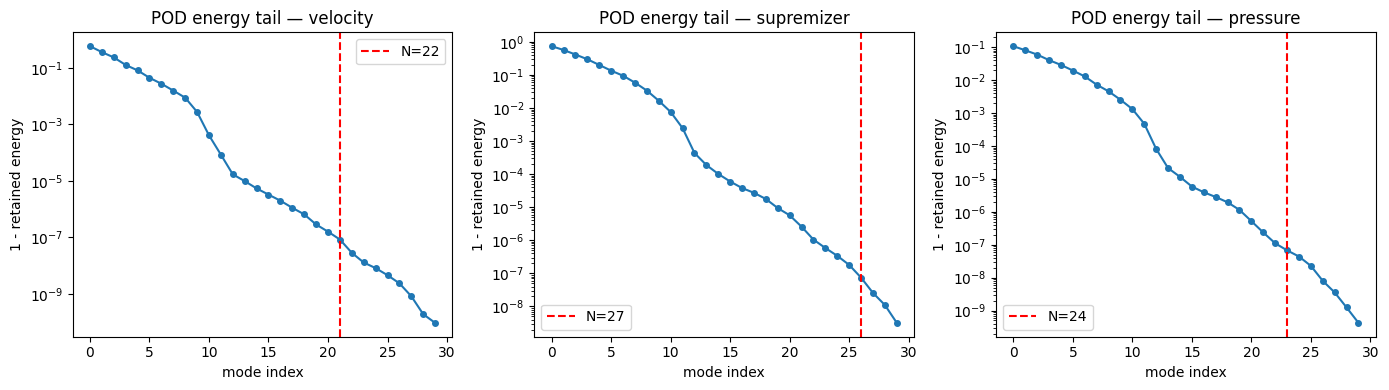

In [13]:
# Covariance matrices.
C_u = snapshot_matrix_u @ inner_product_u @ np.transpose(snapshot_matrix_u)
C_s = snapshot_matrix_s @ inner_product_u @ np.transpose(snapshot_matrix_s)
C_p = snapshot_matrix_p @ np.transpose(snapshot_matrix_p)

N_u, eigs_u, ret_u = eig_analysis(C_u, N_max=N_max, tol=tol)
N_s, eigs_s, ret_s = eig_analysis(C_s, N_max=N_max, tol=tol)
N_p, eigs_p, ret_p = eig_analysis(C_p, N_max=N_max, tol=tol)

print(f"POD dimensions — N_u: {N_u},  N_s: {N_s},  N_p: {N_p}")
print(f"Total reduced dimension: {N_u + N_s + N_p}")

# Energy decay plots.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, ret, label, N in zip(axes, [ret_u, ret_s, ret_p],
                               ['velocity', 'supremizer', 'pressure'],
                               [N_u, N_s, N_p]):
    ax.semilogy(1 - ret[:30], marker='o', markersize=4)
    ax.axvline(N-1, color='r', linestyle='--', label=f'N={N}')
    ax.set_title(f'POD energy tail — {label}')
    ax.set_xlabel('mode index')
    ax.set_ylabel('1 - retained energy')
    ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# Build POD basis matrices.
basis_functions_u = create_basis_functions_matrix(N_u, snapshot_matrix_u, eigs_u, inner_product=inner_product_u)
basis_functions_s = create_basis_functions_matrix(N_s, snapshot_matrix_s, eigs_s, inner_product=inner_product_u)
basis_functions_p = create_basis_functions_matrix(N_p, snapshot_matrix_p, eigs_p)

N_tot = N_u + N_s + N_p
size_u = basis_functions_u.shape[0]   
size_p = basis_functions_p.shape[0]   

global_basis = np.zeros((size_u + size_p, N_tot))
global_basis[0:size_u, 0:N_u]           = basis_functions_u
global_basis[0:size_u, N_u:N_u+N_s]    = basis_functions_s
global_basis[size_u:,  N_u+N_s:]        = basis_functions_p

print(f"Global basis shape: {global_basis.shape}")

# CHECK
# With a purely orthonormal POD basis the Gram matrix G_u = B_u^T X B_u
# should be the identity.  Any deviation means the projection coefficients
# are non-trivially correlated — which makes the NN regression harder.
B_vel_check = global_basis[0:size_u, 0:N_u]          
G_u = B_vel_check.T @ inner_product_u @ B_vel_check   
G_u_err = np.max(np.abs(G_u - np.eye(N_u)))
print(f"  max|G_u - I|     : {G_u_err:.2e}  (should be ~0)")

Global basis shape: (6761, 73)
  max|G_u - I|     : 5.92e-11  (should be ~0)


## Part 4 — POD-NN: Prepare Training Data

For each training snapshot $u_\delta(\boldsymbol\mu^i)$, compute the best-approximation coefficients in $V_N$:

$$
\mathbb{X}_N \, \underline{u}_{\mathsf{rb}}(\boldsymbol\mu^i) = \mathbb{B}^T \mathbb{X}_\delta \, u_\delta(\boldsymbol\mu^i)
$$

where $\mathbb{X}_N = \mathbb{B}^T \mathbb{X}_\delta \mathbb{B}$.

**Fix #1 — Drop supremizers from the NN regression target.**

In an intrusive Galerkin ROM the supremizer enrichment is needed to satisfy the inf-sup condition online.
In POD-NN there is no online Galerkin solve, so supremizers serve no purpose as regression targets.
Worse, the velocity-POD block and the supremizer block are individually orthonormal w.r.t. `inner_product_u`
but are **not** orthogonal to each other, so $\mathbb{X}_N^{\text{vel}} = B_{\text{vel}}^T X B_{\text{vel}}$
is a non-trivial (ill-conditioned) Gram matrix rather than the identity.  Solving the normal equation with a
non-identity Gram matrix produces targets with large magnitudes and strong cross-correlations that a
feed-forward network fits only approximately — and any per-component normalised error is amplified at
reconstruction time.

The fix is simple: use **only the pure velocity POD columns** ($N_u$ columns) as the regression target.
With an orthonormal POD basis $\mathbb{X}_N^{\text{vel}} \approx I$, so the projection coefficients
are simple, well-scaled, and nearly uncorrelated — ideal for NN regression.

The NN will learn the map $\boldsymbol\mu \mapsto \underline{u}_{\mathsf{rb}}(\boldsymbol\mu)$.


In [15]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

B_vel = global_basis[0:size_u, 0:N_u]     
B_prs = global_basis[size_u:,  N_u+N_s:]   

X_N_vel = B_vel.T @ inner_product_u @ B_vel   
X_N_prs = B_prs.T @ B_prs                    

#    net_vel : mu -> coeff_vel  (N_u coefficients — pure velocity POD)
#    net_prs : mu -> coeff_prs  (N_p coefficients)
x_train_np      = np.float32(training_set)        
y_vel_list, y_prs_list = [], []

for i in range(snapshot_matrix_u.shape[0]):
    snap_u = snapshot_matrix_u[i]
    snap_p = snapshot_matrix_p[i]

    rhs_vel   = B_vel.T @ (inner_product_u @ snap_u)
    coeff_vel = np.linalg.solve(X_N_vel, rhs_vel)       

    rhs_prs   = B_prs.T @ snap_p
    coeff_prs = np.linalg.solve(X_N_prs, rhs_prs)       

    y_vel_list.append(coeff_vel)
    y_prs_list.append(coeff_prs)

y_vel_np = np.float32(np.array(y_vel_list))   
y_prs_np = np.float32(np.array(y_prs_list))   

vel_mean, vel_std = y_vel_np.mean(0), y_vel_np.std(0) + 1e-12
prs_mean, prs_std = y_prs_np.mean(0), y_prs_np.std(0) + 1e-12

y_vel_norm = (y_vel_np - vel_mean) / vel_std
y_prs_norm = (y_prs_np - prs_mean) / prs_std

# ── Normalize inputs to [-1, 1] ───────────────────────────────────────────────
mu_min = np.float32(P[:, 0])
mu_max = np.float32(P[:, 1])
x_norm_np = 2.0 * (x_train_np - mu_min) / (mu_max - mu_min) - 1.0

torch.manual_seed(0)

x_train     = torch.tensor(x_norm_np)
y_train_vel = torch.tensor(y_vel_norm)
y_train_prs = torch.tensor(y_prs_norm)

print(f"Train samples : {x_train.shape[0]}")
print(f"Input  shape  : {x_train.shape}   (train x mu_dim)")
print(f"Vel target    : {y_train_vel.shape}   (train x {N_u})  [no supremizers]")
print(f"Prs target    : {y_train_prs.shape}   (train x {N_p})")


Train samples : 200
Input  shape  : torch.Size([200, 2])   (train x mu_dim)
Vel target    : torch.Size([200, 22])   (train x 22)  [no supremizers]
Prs target    : torch.Size([200, 24])   (train x 24)


## Part 5 — Define and Train the Neural Networks

Two independent feedforward NNs with SiLU activations:
- **net_vel**: $\boldsymbol\mu \in \mathbb{R}^2 \to \underline{u}_{\mathsf{rb}} \in \mathbb{R}^{N_u}$ (pure velocity POD coefficients — supremizers dropped)
- **net_prs**: $\boldsymbol\mu \in \mathbb{R}^2 \to \underline{p}_{\mathsf{rb}} \in \mathbb{R}^{N_p}$ (pressure coefficients)

- No train/validation split: the parameter space is low-dimensional ($\boldsymbol\mu \in \mathbb{R}^2$),
  so all snapshots go directly into training and the **training loss** drives the scheduler and early stopping.
- **Early stopping** with patience: training halts when the (smoothed) training loss has not improved for
  `patience` epochs, and the best weights are restored automatically.
- `weight_decay` removed — with normalized outputs and full-batch updates it biases coefficients toward zero.
- `min_lr` set to `1e-6` so the scheduler has room to keep reducing the LR meaningfully.


In [36]:
import torch.optim.lr_scheduler as lr_scheduler
import copy

mu_dim = P.shape[0]   # 2
nodes  = 50

class PODNN(nn.Module):
    def __init__(self, out_dim, hidden=nodes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(mu_dim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, out_dim)
        )
    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
torch.set_default_dtype(torch.float32)

net_vel = PODNN(out_dim=N_u)   
net_prs = PODNN(out_dim=N_p)   

n_vel = sum(p.numel() for p in net_vel.parameters())
n_prs = sum(p.numel() for p in net_prs.parameters())
print(f"net_vel params: {n_vel}   |   net_prs params: {n_prs}")
print(net_vel)


net_vel params: 8922   |   net_prs params: 9024
PODNN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=50, bias=True)
    (1): SiLU()
    (2): Linear(in_features=50, out_features=50, bias=True)
    (3): SiLU()
    (4): Linear(in_features=50, out_features=50, bias=True)
    (5): SiLU()
    (6): Linear(in_features=50, out_features=50, bias=True)
    (7): SiLU()
    (8): Linear(in_features=50, out_features=22, bias=True)
  )
)


In [37]:
loss_fn   = nn.MSELoss()
opt_vel   = torch.optim.Adam(net_vel.parameters(), lr=1e-3)
opt_prs   = torch.optim.Adam(net_prs.parameters(), lr=1e-3)

sched_vel = lr_scheduler.ReduceLROnPlateau(opt_vel, mode='min',
                                            factor=0.5, patience=500, min_lr=1e-6)
sched_prs = lr_scheduler.ReduceLROnPlateau(opt_prs, mode='min',
                                            factor=0.5, patience=500, min_lr=1e-6)


epoch_max      = 200_000
es_patience    = 3_000    # consecutive epochs without smoothed-train improvement
es_min_epoch   = 10_000   # early stopping cannot fire before this epoch
smooth_window  = 200      # epochs to average for the smoothed train signal

best_train_vel = float('inf')
best_train_prs = float('inf')
best_wts_vel   = copy.deepcopy(net_vel.state_dict())
best_wts_prs   = copy.deepcopy(net_prs.state_dict())
no_improve_vel = 0
no_improve_prs = 0
stopped_vel    = False
stopped_prs    = False

hist_vel, hist_prs = [], []

epoch = 0

while epoch < epoch_max and not (stopped_vel and stopped_prs):
    epoch += 1

    # ── velocity network ──────────────────────────────────────────────────────
    if not stopped_vel:
        net_vel.train()
        opt_vel.zero_grad()
        loss_vel = loss_fn(net_vel(x_train), y_train_vel)
        loss_vel.backward()
        opt_vel.step()

        hist_vel.append(loss_vel.item())

        # Smooth the training signal before feeding the scheduler and early stopping
        smooth_vel = float(np.mean(hist_vel[-smooth_window:]))
        sched_vel.step(smooth_vel)

        if epoch >= es_min_epoch:
            if smooth_vel < best_train_vel:
                best_train_vel = smooth_vel
                best_wts_vel = copy.deepcopy(net_vel.state_dict())
                no_improve_vel = 0
            else:
                no_improve_vel += 1
                if no_improve_vel >= es_patience:
                    stopped_vel = True
                    net_vel.load_state_dict(best_wts_vel)
                    print(f"  [epoch {epoch}] net_vel early stopped — "
                          f"best smoothed train loss {best_train_vel:.4e}")

    # ── pressure network ──────────────────────────────────────────────────────
    if not stopped_prs:
        net_prs.train()
        opt_prs.zero_grad()
        loss_prs = loss_fn(net_prs(x_train), y_train_prs)
        loss_prs.backward()
        opt_prs.step()

        hist_prs.append(loss_prs.item())

        smooth_prs = float(np.mean(hist_prs[-smooth_window:]))
        sched_prs.step(smooth_prs)

        if epoch >= es_min_epoch:
            if smooth_prs < best_train_prs:
                best_train_prs = smooth_prs
                best_wts_prs = copy.deepcopy(net_prs.state_dict())
                no_improve_prs = 0
            else:
                no_improve_prs += 1
                if no_improve_prs >= es_patience:
                    stopped_prs = True
                    net_prs.load_state_dict(best_wts_prs)
                    print(f"  [epoch {epoch}] net_prs early stopped — "
                          f"best smoothed train loss {best_train_prs:.4e}")

    if epoch % 5_000 == 0:
        lr_vel_now = opt_vel.param_groups[0]['lr']
        lr_prs_now = opt_prs.param_groups[0]['lr']
        sv = float(np.mean(hist_vel[-smooth_window:])) if hist_vel else float('nan')
        sp = float(np.mean(hist_prs[-smooth_window:])) if hist_prs else float('nan')
        print(f"  epoch {epoch:>7d} | "
              f"vel: smooth-train {sv:.4e} (lr: {lr_vel_now:.1e}) | "
              f"prs: smooth-train {sp:.4e} (lr: {lr_prs_now:.1e})")

# Restore best weights (also covers the max-epoch case)
net_vel.load_state_dict(best_wts_vel)
net_prs.load_state_dict(best_wts_prs)

print(f"\nFinished at epoch {epoch}")
print(f"  best smoothed train_vel = {best_train_vel:.4e}   "
      f"best smoothed train_prs = {best_train_prs:.4e}")


  epoch    5000 | vel: smooth-train 1.2113e-03 (lr: 1.0e-03) | prs: smooth-train 1.3237e-03 (lr: 1.0e-03)
  epoch   10000 | vel: smooth-train 4.4341e-04 (lr: 5.0e-04) | prs: smooth-train 4.8983e-04 (lr: 2.5e-04)
  epoch   15000 | vel: smooth-train 3.1587e-04 (lr: 2.5e-04) | prs: smooth-train 3.3441e-04 (lr: 2.5e-04)
  epoch   20000 | vel: smooth-train 2.4530e-04 (lr: 2.5e-04) | prs: smooth-train 2.6397e-04 (lr: 2.5e-04)
  epoch   25000 | vel: smooth-train 2.0017e-04 (lr: 2.5e-04) | prs: smooth-train 1.7835e-04 (lr: 1.3e-04)
  epoch   30000 | vel: smooth-train 1.6177e-04 (lr: 1.3e-04) | prs: smooth-train 1.4310e-04 (lr: 6.3e-05)
  epoch   35000 | vel: smooth-train 1.4197e-04 (lr: 1.3e-04) | prs: smooth-train 1.1678e-04 (lr: 6.3e-05)
  epoch   40000 | vel: smooth-train 1.2472e-04 (lr: 1.3e-04) | prs: smooth-train 1.0022e-04 (lr: 6.3e-05)
  epoch   45000 | vel: smooth-train 1.1199e-04 (lr: 1.3e-04) | prs: smooth-train 8.8603e-05 (lr: 6.3e-05)
  epoch   50000 | vel: smooth-train 1.0139e-04

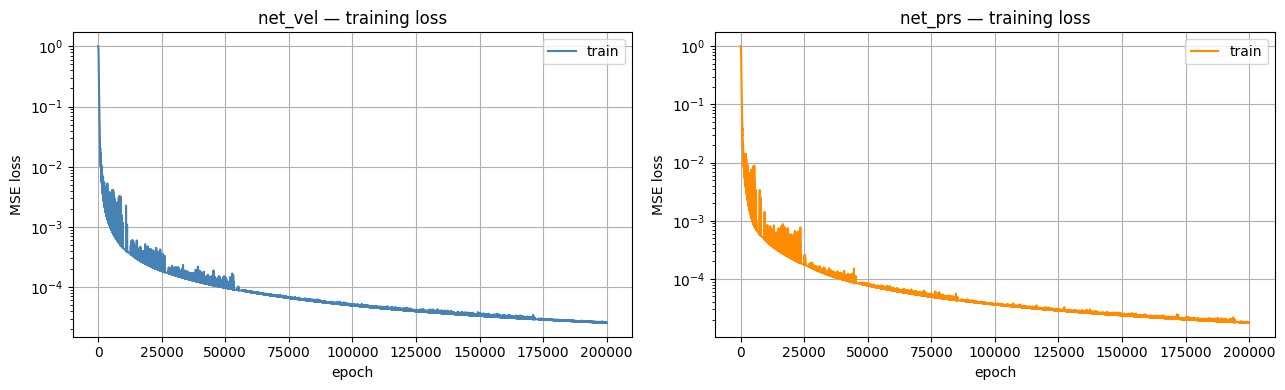

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].semilogy(hist_vel, color='steelblue', label='train')
axes[0].set_title('net_vel — training loss')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('MSE loss')
axes[0].legend(); axes[0].grid(True)

axes[1].semilogy(hist_prs, color='darkorange', label='train')
axes[1].set_title('net_prs — training loss')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('MSE loss')
axes[1].legend(); axes[1].grid(True)

#plt.suptitle('POD-NN — separate velocity and pressure networks', fontsize=11)
plt.tight_layout()
plt.savefig("podnn_training_loss.png", dpi=300, bbox_inches="tight")
plt.show()


## Part 6 — Online Phase: POD-NN Prediction

Given a new $\boldsymbol\mu_{\text{test}}$:
1. Forward pass through NN → reduced coefficients $\underline{u}_{\mathsf{rb}}^{NN}$ (size $N_u$)
2. Reconstruct FE solution: $u_h \approx B_{\text{vel}} \, \underline{u}_{\mathsf{rb}}^{NN}$

**No linear solve. No assembly. No projection.**

To reveal the true $\mu$-dependent trend we test at points **strictly inside the box**:
$\mu_0 \in [0.5, 9.5]$, $\mu_1 \in [1.2, 2.8]$, with an inner margin of ~5% on each side.


Testing with mu_test = [2, 1.5]
  Newton iter 1: residual = 2.2240e+00
  Newton iter 2: residual = 1.9434e-03
  Newton iter 3: residual = 1.8842e-10

--- POD-NN solution ---


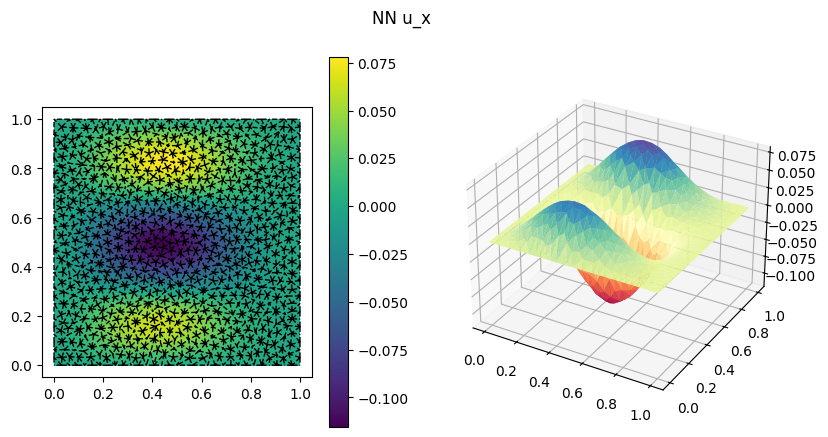

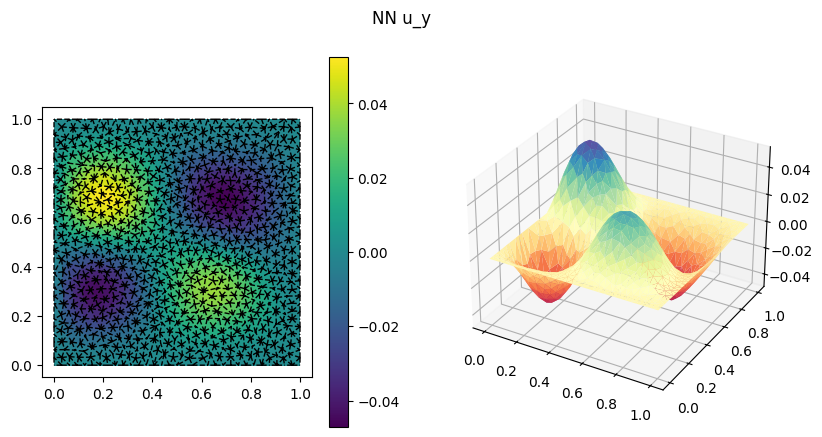

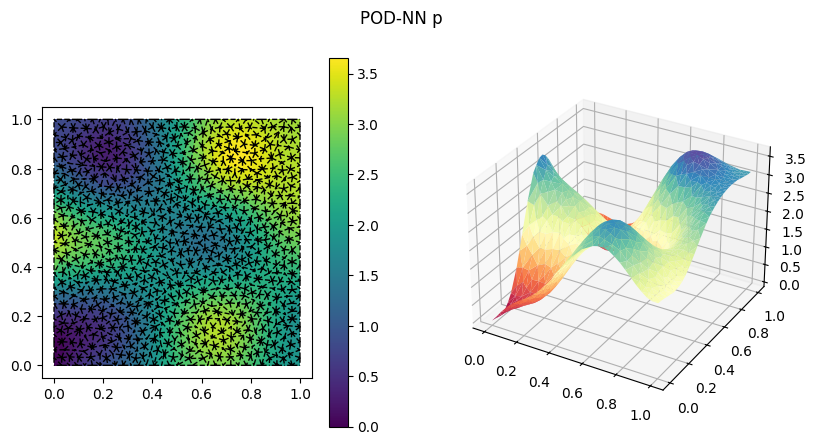

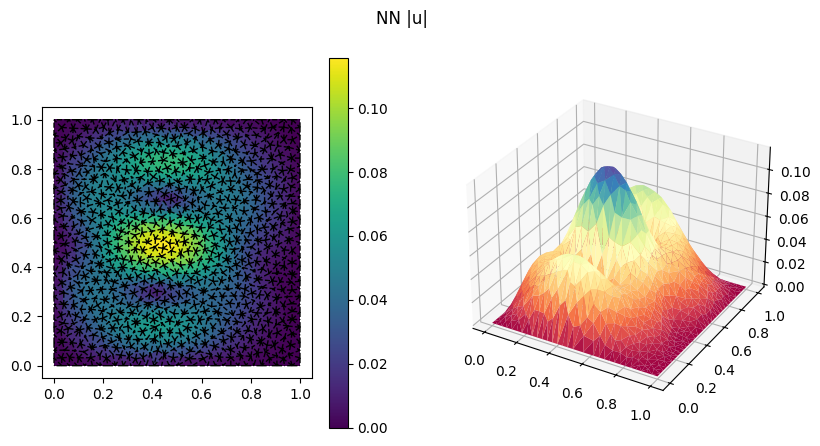


--- FOM solution ---


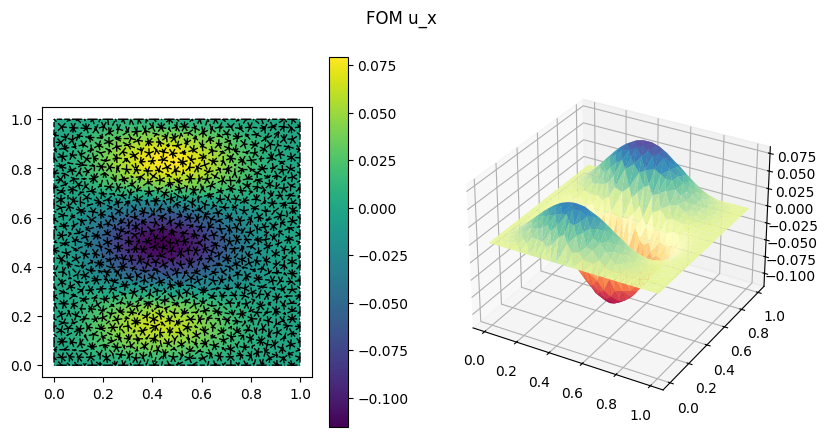

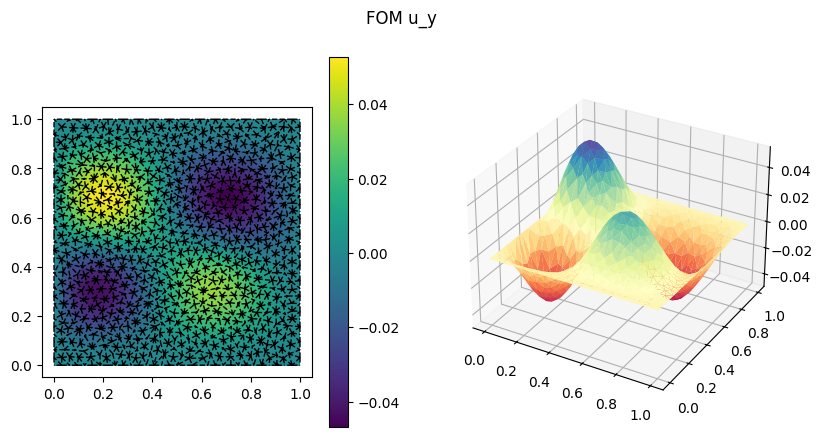

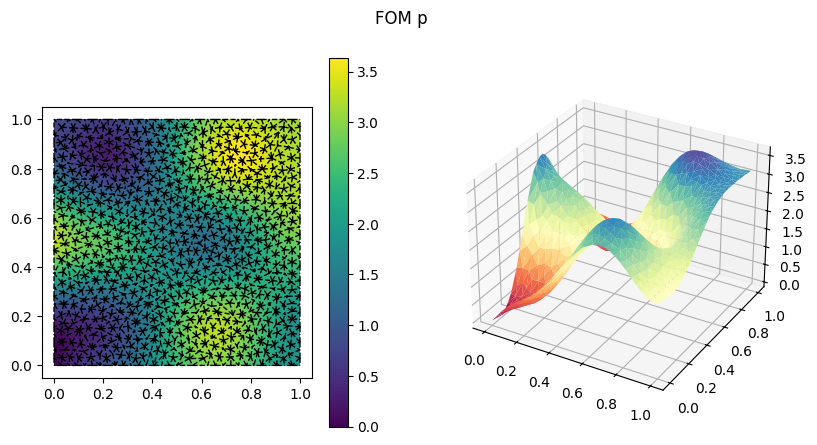

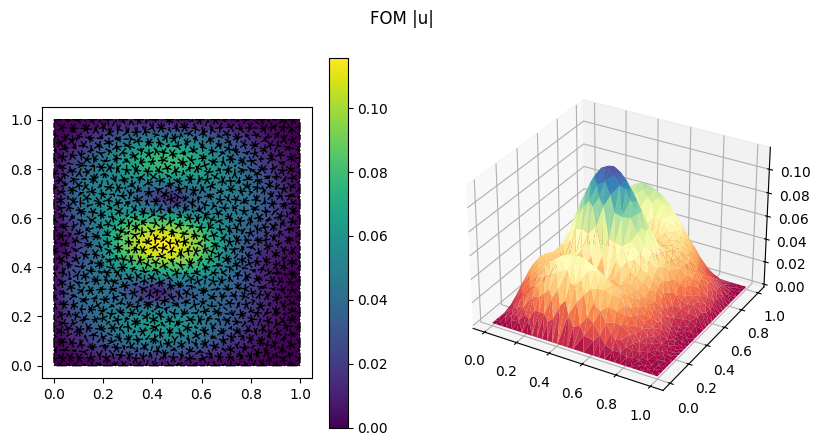

In [39]:
mu_test = [2, 1.5]  
print(f"Testing with mu_test = {mu_test}")

# Normalize input the same way as during training.
x_test_np = 2.0 * (np.float32(mu_test) - mu_min) / (mu_max - mu_min) - 1.0
x_test     = torch.tensor(x_test_np[None, :])          # shape (1, 2)

# ── POD-NN prediction ─────────────────────────────────────────────────────────
net_vel.eval(); net_prs.eval()
with torch.no_grad():
    coeff_vel_norm = net_vel(x_test).numpy()[0]        
    coeff_prs_norm = net_prs(x_test).numpy()[0]

# De-normalize
coeff_vel = coeff_vel_norm * vel_std + vel_mean
coeff_prs = coeff_prs_norm * prs_std + prs_mean

# Reconstruct FE solution from the two coefficient vectors.
nn_solution_vel = B_vel @ coeff_vel  
nn_solution_prs = B_prs @ coeff_prs  

nn_u_x = nn_solution_vel[0:speed_n_dofs]
nn_u_y = nn_solution_vel[speed_n_dofs:2*speed_n_dofs]
nn_p   = nn_solution_prs

# FOM reference for comparison.
fom_solution = solve_ns(mu_test, verbose=True)
fom_u_x = fom_solution[0:speed_n_dofs]
fom_u_y = fom_solution[speed_n_dofs:2*speed_n_dofs]
fom_p_  = fom_solution[2*speed_n_dofs:]

u_x_strong_test = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
    geometry_utilities, mesh, mesh_geometric_data,
    speed_mesh_dofs_info, speed_dofs_data, speed_reference_element_data,
    speed_x_strong_function)
u_y_strong_test = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
    geometry_utilities, mesh, mesh_geometric_data,
    speed_mesh_dofs_info, speed_dofs_data, speed_reference_element_data,
    speed_y_strong_function)
p_strong_test = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
    geometry_utilities, mesh, mesh_geometric_data,
    pressure_mesh_dofs_info, pressure_dofs_data, pressure_reference_element_data,
    pressure_strong_function)

# Plot POD-NN velocity.
print("\n--- POD-NN solution ---")
nn_ux_cell = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(
    mesh, speed_dofs_data, nn_u_x, u_x_strong_test)
nn_uy_cell = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(
    mesh, speed_dofs_data, nn_u_y, u_y_strong_test)
nn_p_cell = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(
    mesh, pressure_dofs_data, nn_p, p_strong_test)

other_ut.plot_solution(mesh, nn_ux_cell.numeric_solution, "NN u_x")
plt.savefig("NN_u_x.png", dpi=300, bbox_inches="tight")
plt.close()

other_ut.plot_solution(mesh, nn_uy_cell.numeric_solution, "NN u_y")
plt.savefig("NN_u_y.png", dpi=300, bbox_inches="tight")
plt.close()

other_ut.plot_solution(mesh, nn_p_cell.numeric_solution, "POD-NN p")
plt.savefig("NN_p.png", dpi=300, bbox_inches="tight")
plt.close()

other_ut.plot_solution(mesh, np.sqrt(nn_ux_cell.numeric_solution**2 + nn_uy_cell.numeric_solution**2), "NN |u|")
plt.savefig("NN_umag.png", dpi=300, bbox_inches="tight")
plt.close()

# Plot FOM velocity.
print("\n--- FOM solution ---")
fom_ux_cell = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(
    mesh, speed_dofs_data, fom_u_x, u_x_strong_test)
fom_uy_cell = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(
    mesh, speed_dofs_data, fom_u_y, u_y_strong_test)
fom_p_cell = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(
    mesh, pressure_dofs_data, fom_p_, p_strong_test)
other_ut.plot_solution(mesh, fom_ux_cell.numeric_solution, "FOM u_x")
plt.savefig("FOM_u_x.png", dpi=300, bbox_inches="tight")
plt.close()

other_ut.plot_solution(mesh, fom_uy_cell.numeric_solution, "FOM u_y")
plt.savefig("FOM_u_y.png", dpi=300, bbox_inches="tight")
plt.close()

other_ut.plot_solution(mesh, fom_p_cell.numeric_solution, "FOM p")
plt.savefig("FOM_p.png", dpi=300, bbox_inches="tight")
plt.close()

other_ut.plot_solution(mesh, np.sqrt(fom_ux_cell.numeric_solution**2 + fom_uy_cell.numeric_solution**2), "FOM |u|")
plt.savefig("FOM_umag.png", dpi=300, bbox_inches="tight")
plt.close()


In [40]:
def compute_error(fom_solution, rom_solution, inner_product=None, type_err="relative"):
    """Compute absolute or relative error in the given norm."""
    error = fom_solution - rom_solution
    if inner_product is None:
        inner_product = np.eye(len(fom_solution))
    err2 = np.transpose(error) @ inner_product @ error
    abs_err = np.sqrt(abs(err2))
    if type_err == "absolute":
        return abs_err
    sol2 = np.transpose(fom_solution) @ inner_product @ fom_solution
    return abs_err / np.sqrt(abs(sol2))

In [41]:
fom_u_tot = np.concatenate([fom_u_x, fom_u_y])
nn_u_tot = np.concatenate([nn_u_x, nn_u_y])
rel_err_u = (compute_error(fom_u_tot, nn_u_tot, inner_product=inner_product_u))
rel_err_p = (compute_error(fom_p_, nn_p))
print(f"Relative error (velocity) : {(rel_err_u):.4e}")
print(f"Relative error (pressure) : {(rel_err_p):.4e}")

Relative error (velocity) : 5.4053e-02
Relative error (pressure) : 6.3502e-03


In [42]:
import numpy as np
import time

mu0_lo, mu0_hi = 0.5,  9.5    
mu1_lo, mu1_hi = 1.2,  2.8    

test_cases = {
    "Worst Case (Low Visc, High mu1)":  [mu0_lo, mu1_hi],  # high Re
    "Best Case  (High Visc, Low mu1)":  [mu0_hi, mu1_lo],  # low  Re
    "Center Case (Average)":            [(mu0_lo+mu0_hi)/2, (mu1_lo+mu1_hi)/2],
    "Low Visc, Low mu1":                [mu0_lo, mu1_lo],
    "High Visc, High mu1":              [mu0_hi, mu1_hi],
}

def pod_proj_u(fom_u):
    """Project FOM velocity onto the pure POD basis and reconstruct."""
    coeff = np.linalg.solve(X_N_vel, B_vel.T @ (inner_product_u @ fom_u))
    return B_vel @ coeff

def pod_proj_p(fom_p):
    coeff = np.linalg.solve(X_N_prs, B_prs.T @ fom_p)
    return B_prs @ coeff

print(f"{'Test Case':<36} | {'mu0':>5} {'mu1':>5} | "
      f"{'POD err_u':>10} {'POD err_p':>10} | "
      f"{'NN  err_u':>10} {'NN  err_p':>10}")
print("-" * 100)

net_vel.eval()
net_prs.eval()

for name, mu_val in test_cases.items():
    # ── Normalize input ───────────────────────────────────────────────────────
    x_test_np = 2.0 * (np.float32(mu_val) - mu_min) / (mu_max - mu_min) - 1.0
    x_test = torch.tensor(x_test_np[None, :])

    # ── POD-NN prediction ─────────────────────────────────────────────────────
    with torch.no_grad():
        coeff_vel = net_vel(x_test).numpy()[0] * vel_std + vel_mean
        coeff_prs = net_prs(x_test).numpy()[0] * prs_std + prs_mean

    nn_vel = B_vel @ coeff_vel                          
    nn_p   = B_prs @ coeff_prs                               
    nn_u_tot = nn_vel                                          

    # ── FOM reference ─────────────────────────────────────────────────────────
    fom_sol   = solve_ns(mu_val, verbose=False)
    fom_u_tot = fom_sol[0:2*speed_n_dofs]
    fom_p_vec = fom_sol[2*speed_n_dofs:]

    # ── POD projection error ──────────────────────────────────────────────────
    pod_u = pod_proj_u(fom_u_tot)
    pod_p = pod_proj_p(fom_p_vec)

    def rel_err_ip(u, v, X=None):
        d = u - v
        if X is None:
            return np.linalg.norm(d) / (np.linalg.norm(u) + 1e-300)
        return np.sqrt(d @ X @ d) / (np.sqrt(u @ X @ u) + 1e-300)

    pod_err_u = rel_err_ip(fom_u_tot, pod_u, X=inner_product_u)
    pod_err_p = rel_err_ip(fom_p_vec, pod_p)
    nn_err_u  = rel_err_ip(fom_u_tot, nn_u_tot, X=inner_product_u)
    nn_err_p  = rel_err_ip(fom_p_vec, nn_p)

    print(f"{name:<36} | {mu_val[0]:5.2f} {mu_val[1]:5.2f} | "
          f"{pod_err_u:10.3e} {pod_err_p:10.3e} | "
          f"{nn_err_u:10.3e} {nn_err_p:10.3e}")

print()

Test Case                            |   mu0   mu1 |  POD err_u  POD err_p |  NN  err_u  NN  err_p
----------------------------------------------------------------------------------------------------
Worst Case (Low Visc, High mu1)      |  0.50  2.80 |  9.678e-04  6.900e-04 |  3.435e-01  5.485e-02
Best Case  (High Visc, Low mu1)      |  9.50  1.20 |  1.187e-03  1.619e-04 |  2.714e-02  2.379e-03
Center Case (Average)                |  5.00  2.00 |  6.457e-04  1.580e-04 |  2.225e-02  1.538e-03
Low Visc, Low mu1                    |  0.50  1.20 |  2.640e-04  7.084e-04 |  2.729e-01  2.152e-01
High Visc, High mu1                  |  9.50  2.80 |  2.571e-04  2.308e-04 |  3.810e-02  1.322e-03



## Part 7 — Error Analysis and Speed-Up

Compare POD-NN vs FOM over a testing set. The online cost is only a NN forward pass — **no assembly, no linear solve** — which guarantees a real speed-up regardless of affinity.

In [43]:
np.random.seed(42)
P_interior = np.array([[0.5, 9.5], [1.2, 2.8]])
testing_set = np.random.uniform(low=P_interior[:, 0], high=P_interior[:, 1],
                                size=(200, P.shape[0]))

abs_err_u, rel_err_u = [], []
abs_err_p, rel_err_p = [], []
abs_err_pod_u, rel_err_pod_u = [], []   
abs_err_pod_p, rel_err_pod_p = [], []
speed_up_nn = []

net_vel.eval(); net_prs.eval()
print("Running error and speed-up analysis...")

for it, mu in enumerate(testing_set):
    if it % 20 == 0:
        print(f"  Test {it}/{len(testing_set)}")

    # === FOM ===
    start_fom = time.time()
    full_solution = solve_ns(mu)
    time_fom = time.time() - start_fom

    full_u = full_solution[0:2*speed_n_dofs]
    full_p = full_solution[2*speed_n_dofs:]

    # === POD projection ===
    pod_u  = B_vel @ np.linalg.solve(X_N_vel, B_vel.T @ (inner_product_u @ full_u))
    pod_p  = B_prs @ np.linalg.solve(X_N_prs, B_prs.T @ full_p)

    # === POD-NN  ===
    mu_norm = 2.0 * (np.float32(mu) - mu_min) / (mu_max - mu_min) - 1.0
    x_t = torch.tensor(mu_norm[None, :])

    start_nn = time.time()
    with torch.no_grad():
        cv_norm = net_vel(x_t).numpy()[0]
        cp_norm = net_prs(x_t).numpy()[0]
    cv = cv_norm * vel_std + vel_mean
    cp = cp_norm * prs_std + prs_mean
    nn_u = B_vel @ cv     
    nn_p = B_prs @ cp 
    time_nn = time.time() - start_nn

    speed_up_nn.append(time_fom / time_nn)

    # === Errors (H1-seminorm for velocity, L2 for pressure) ===
    abs_err_u.append(compute_error(full_u, nn_u, inner_product=inner_product_u, type_err="absolute"))
    rel_err_u.append(compute_error(full_u, nn_u, inner_product=inner_product_u))
    abs_err_p.append(compute_error(full_p, nn_p, type_err="absolute"))
    rel_err_p.append(compute_error(full_p, nn_p))

    abs_err_pod_u.append(compute_error(full_u, pod_u, inner_product=inner_product_u, type_err="absolute"))
    rel_err_pod_u.append(compute_error(full_u, pod_u, inner_product=inner_product_u))
    abs_err_pod_p.append(compute_error(full_p, pod_p, type_err="absolute"))
    rel_err_pod_p.append(compute_error(full_p, pod_p))

print("\n=== POD-NN Results ===")
print(f"{'Metric':<40} {'Velocity':>12} {'Pressure':>12}")
print(f"{'POD truncation — mean rel. error':40} {np.mean(rel_err_pod_u):12.4e} {np.mean(rel_err_pod_p):12.4e}")
print(f"{'POD-NN — mean relative error':40} {np.mean(rel_err_u):12.4e} {np.mean(rel_err_p):12.4e}")
print(f"{'POD-NN — mean absolute error':40} {np.mean(abs_err_u):12.4e} {np.mean(abs_err_p):12.4e}")
print(f"{'NN overhead (NN err / POD err)':40} {np.mean(rel_err_u)/np.mean(rel_err_pod_u):12.2f}x {np.mean(rel_err_p)/np.mean(rel_err_pod_p):12.2f}x")
print(f"{'Mean speed-up (NN vs FOM)':40} {np.mean(speed_up_nn):12.1f}x")
print()

Running error and speed-up analysis...
  Test 0/200
  Test 20/200
  Test 40/200
  Test 60/200
  Test 80/200
  Test 100/200
  Test 120/200
  Test 140/200
  Test 160/200
  Test 180/200

=== POD-NN Results ===
Metric                                       Velocity     Pressure
POD truncation — mean rel. error           8.1933e-04   2.2148e-04
POD-NN — mean relative error               8.6262e-02   1.8816e-02
POD-NN — mean absolute error               9.0650e-02   1.8046e+00
NN overhead (NN err / POD err)                 105.28x        84.96x
Mean speed-up (NN vs FOM)                      1702.6x



In [44]:
print("Mean FOM time :", np.mean(time_fom))
print("Mean NN time  :", np.mean(time_nn))

Mean FOM time : 1.1256804466247559
Mean NN time  : 0.0005466938018798828


---
## Part 8 — POD-NN Validation with a Manufactured Exact Solution

Up to this point every error was measured relative to the FOM solution, which is itself only an approximation.
Here we verify the **full pipeline** — FOM snapshots → POD basis → NN training → online prediction — against a
problem whose true solution is known analytically.

### Exact solution
$$
u = +\tfrac{1}{2}\sin^2(2\pi x)\sin(2\pi y)\cos(2\pi y), \qquad
v = -\tfrac{1}{2}\sin^2(2\pi y)\sin(2\pi x)\cos(2\pi x), \qquad
p = \pi^2\sin(2\pi x)\cos(2\pi y)
$$

BCs: $\mathbf{u}=0$ on $\partial\Omega$ ✓ — Incompressibility: $\partial_x u+\partial_y v=0$ ✓

### Strategy
1. **Re-train a fresh POD-NN** on the same mesh and parameter space, but with the body force
   $\mathbf{f} = -\mu_0\Delta\mathbf{u} + (\mathbf{u}\cdot\nabla)\mathbf{u} + \nabla p$
   manufactured from the exact solution.
2. For a sweep of $\mu_0$ values, compare the POD-NN prediction against the true $(u,v,p)$ using
   `compute_error_l2`.
3. Compare those errors against the FOM errors on the same instances — the POD-NN error should be
   only slightly larger than the FOM discretisation error.

### 8.1 — Exact solution functions and manufactured body force

In [45]:
def u_exact(x, y):
    return 0.5 * np.sin(2*np.pi*x)**2 * np.sin(2*np.pi*y) * np.cos(2*np.pi*y)

def v_exact(x, y):
    return -0.5 * np.sin(2*np.pi*y)**2 * np.sin(2*np.pi*x) * np.cos(2*np.pi*x)

def p_exact(x, y):
    return np.pi**2 * np.sin(2*np.pi*x) * np.cos(2*np.pi*y)

def lap_u(x, y):
    return (4*np.pi**2
            * (-3*np.sin(2*np.pi*x)**2 + np.cos(2*np.pi*x)**2)
            * np.sin(2*np.pi*y) * np.cos(2*np.pi*y))

def lap_v(x, y):
    return (4*np.pi**2
            * (-16*np.sin(np.pi*y)**4 + 16*np.sin(np.pi*y)**2 - 1)
            * np.sin(2*np.pi*x) * np.cos(2*np.pi*x))

def conv_u(x, y):
    return 0.5*np.pi * np.sin(2*np.pi*x)**3 * np.sin(2*np.pi*y)**2 * np.cos(2*np.pi*x)

def conv_v(x, y):
    return 0.5*np.pi * np.sin(2*np.pi*x)**2 * np.sin(2*np.pi*y)**3 * np.cos(2*np.pi*y)

def grad_px(x, y):  return  2*np.pi**3 * np.cos(2*np.pi*x) * np.cos(2*np.pi*y)
def grad_py(x, y):  return -2*np.pi**3 * np.sin(2*np.pi*x) * np.sin(2*np.pi*y)

def fx_manuf(x, y, z, mu0):
    return -mu0 * lap_u(x, y) + conv_u(x, y) + grad_px(x, y)

def fy_manuf(x, y, z, mu0):
    return -mu0 * lap_v(x, y) + conv_v(x, y) + grad_py(x, y)

def ux_exact_fn(x, y, z):  return u_exact(x, y)
def uy_exact_fn(x, y, z):  return v_exact(x, y)
def p_exact_fn(x, y, z):   return p_exact(x, y)

_xs = np.linspace(0.05, 0.95, 30)
_XX, _YY = np.meshgrid(_xs, _xs)
_div = (2*np.pi*np.sin(2*np.pi*_XX)*np.cos(2*np.pi*_XX)*np.sin(2*np.pi*_YY)*np.cos(2*np.pi*_YY)
       -2*np.pi*np.sin(2*np.pi*_YY)*np.cos(2*np.pi*_YY)*np.sin(2*np.pi*_XX)*np.cos(2*np.pi*_XX))
print(f"max |div(u,v)| = {np.max(np.abs(_div)):.2e}  (must be 0)")

max |div(u,v)| = 4.44e-16  (must be 0)


### 8.2 — FOM solver that uses the manufactured body force

We reuse `solve_ns` from Part 2 but pass the manufactured force instead of the original `f_x_function`.
Everything else (mesh, FE space, Newton loop) is identical — this is deliberately the same infrastructure.

In [46]:
def solve_ns_manuf(mu, newton_tol=1.0e-8, max_iterations=20, verbose=False):
    mu0 = mu[0]
    
    f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_reference_element_data, speed_reference_element_data,
        lambda x, y, z: fx_manuf(x, y, z, mu0))
    f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_reference_element_data, speed_reference_element_data,
        lambda x, y, z: fy_manuf(x, y, z, mu0))
    f_S = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])

    u_x_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_mesh_dofs_info, speed_dofs_data, speed_reference_element_data,
        speed_x_strong_function)
    u_y_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_mesh_dofs_info, speed_dofs_data, speed_reference_element_data,
        speed_y_strong_function)

    A_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_diffusion_operator(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_dofs_data,
        speed_reference_element_data, speed_reference_element_data,
        lambda x, y, z: mu0)
    B_x_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, pressure_dofs_data,
        speed_reference_element_data, pressure_reference_element_data,
        b_x_term)
    B_y_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, pressure_dofs_data,
        speed_reference_element_data, pressure_reference_element_data,
        b_y_term)

    J_A_x  = other_ut.make_np_sparse(A_operator.operator_dofs,   [tot_dofs, tot_dofs], [0, 0])
    J_A_y  = other_ut.make_np_sparse(A_operator.operator_dofs,   [tot_dofs, tot_dofs], [speed_n_dofs, speed_n_dofs])
    J_B_x  = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2*speed_n_dofs, 0])
    J_B_y  = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2*speed_n_dofs, speed_n_dofs])
    J_BT_x = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2*speed_n_dofs, 0], True)
    J_BT_y = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2*speed_n_dofs, speed_n_dofs], True)
    J_S = J_A_x + J_A_y - J_B_x - J_B_y - J_BT_x - J_BT_y

    u_x_num = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_reference_element_data, speed_x_initial_condition).function_dofs
    u_y_num = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(
        geometry_utilities, mesh, mesh_geometric_data,
        speed_dofs_data, speed_reference_element_data, speed_y_initial_condition).function_dofs
    p_num   = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(
        geometry_utilities, mesh, mesh_geometric_data,
        pressure_dofs_data, pressure_reference_element_data, pressure_initial_condition).function_dofs
    u_k = np.concatenate([u_x_num, u_y_num, p_num])

    du_x_strong = np.zeros(speed_n_strongs)
    du_y_strong = np.zeros(speed_n_strongs)
    dp_strong   = np.zeros(pressure_n_strongs)

    residual_norm = 1.0;  solution_norm = 1.0
    for it in range(1, max_iterations + 1):
        c_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_ns_operators(
            geometry_utilities, mesh, mesh_geometric_data,
            speed_dofs_data, speed_reference_element_data,
            u_k[0:speed_n_dofs], u_k[speed_n_dofs:2*speed_n_dofs],
            u_x_strong, u_y_strong)
        J_C = other_ut.make_np_sparse(
            c_operator.convective_operator.operator_dofs, [tot_dofs, tot_dofs], [0, 0])
        f_C = np.concatenate([c_operator.convective_rhs, np.zeros(pressure_n_dofs)])

        rhs = f_S - f_C - J_S @ u_k
        du  = scipy.sparse.linalg.spsolve(J_S + J_C, rhs)
        u_k = u_k + du

        du_x = du[0:speed_n_dofs];  du_y = du[speed_n_dofs:2*speed_n_dofs];  dp = du[2*speed_n_dofs:]
        u_k[0:speed_n_dofs]           = u_k[0:speed_n_dofs]
        u_k[speed_n_dofs:2*speed_n_dofs] = u_k[speed_n_dofs:2*speed_n_dofs]

        ex = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities, mesh, mesh_geometric_data,
            speed_dofs_data, speed_reference_element_data, du_x, du_x_strong)
        ey = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities, mesh, mesh_geometric_data,
            speed_dofs_data, speed_reference_element_data, du_y, du_y_strong)
        ep = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities, mesh, mesh_geometric_data,
            pressure_dofs_data, pressure_reference_element_data, dp, dp_strong)
        residual_norm = np.sqrt(ex.numeric_norm_l2**2 + ey.numeric_norm_l2**2 + ep.numeric_norm_l2**2)
        if verbose:
            print(f"  Newton {it}: |res| = {residual_norm:.3e}")
        if residual_norm < newton_tol * max(solution_norm, 1e-12):
            break

    return u_k

### 8.3 — Retrain POD-NN on the manufactured problem

Same parameter space $\mu_0\in[0.1,10]$, $\mu_1\in[1,3]$, same snapshot count.
A smaller hidden width (64) is used because the problem is simpler.
The same approach as Part 5 applies: no train/val split (the problem is
low-dimensional), training loss drives `ReduceLROnPlateau` and early
stopping, and no `weight_decay`.

Note: the manufactured exact solution does **not** depend on $\mu_1$, so the NN
only needs to learn the viscosity dependence — errors should be close to the FOM floor.


In [47]:
snapshot_num_val = 100
np.random.seed(7)
training_set_val = np.random.uniform(low=P[:, 0], high=P[:, 1],
                                      size=(snapshot_num_val, P.shape[0]))

snap_u_val, snap_s_val, snap_p_val = [], [], []

print("Collecting manufactured snapshots...")
for it, mu in enumerate(training_set_val):
    if it % 20 == 0:
        print(f"  Snapshot {it}/{snapshot_num_val}  mu0={mu[0]:.3f}")
    u_k = solve_ns_manuf(mu)
    su = u_k[0:2*speed_n_dofs]
    sp_  = u_k[2*speed_n_dofs:]
    ss = scipy.sparse.linalg.spsolve(X_1 + X_2, np.transpose(B_1 + B_2) @ sp_)
    snap_u_val.append(np.copy(su))
    snap_s_val.append(np.copy(ss))
    snap_p_val.append(np.copy(sp_))

snap_u_val = np.array(snap_u_val)
snap_s_val = np.array(snap_s_val)
snap_p_val = np.array(snap_p_val)
print("Done.")

  Snapshot 0/100  mu0=0.855
  Snapshot 20/100  mu0=4.583
  Snapshot 40/100  mu0=1.738
  Snapshot 60/100  mu0=2.318
  Snapshot 80/100  mu0=0.205
Done.


In [48]:
C_u_v = snap_u_val @ inner_product_u @ snap_u_val.T
C_s_v = snap_s_val @ inner_product_u @ snap_s_val.T
C_p_v = snap_p_val @ snap_p_val.T

N_u_v, eigs_u_v, ret_u_v = eig_analysis(C_u_v, N_max=N_max, tol=tol)
N_s_v, eigs_s_v, ret_s_v = eig_analysis(C_s_v, N_max=N_max, tol=tol)
N_p_v, eigs_p_v, ret_p_v = eig_analysis(C_p_v, N_max=N_max, tol=tol)
print(f"POD dims (manuf.) — N_u: {N_u_v},  N_s: {N_s_v},  N_p: {N_p_v}")

bf_u_v = create_basis_functions_matrix(N_u_v, snap_u_val, eigs_u_v, inner_product=inner_product_u)
bf_s_v = create_basis_functions_matrix(N_s_v, snap_s_val, eigs_s_v, inner_product=inner_product_u)
bf_p_v = create_basis_functions_matrix(N_p_v, snap_p_val, eigs_p_v)

N_tot_v  = N_u_v + N_s_v + N_p_v
size_u_v = bf_u_v.shape[0]
size_p_v = bf_p_v.shape[0]

global_basis_val = np.zeros((size_u_v + size_p_v, N_tot_v))
global_basis_val[0:size_u_v, 0:N_u_v]              = bf_u_v
global_basis_val[0:size_u_v, N_u_v:N_u_v+N_s_v]   = bf_s_v
global_basis_val[size_u_v:,  N_u_v+N_s_v:]         = bf_p_v
print(f"Global basis shape (incl. supremizers): {global_basis_val.shape}")


POD dims (manuf.) — N_u: 2,  N_s: 2,  N_p: 2
Global basis shape (incl. supremizers): (6761, 6)


In [49]:
B_vel_v = global_basis_val[0:size_u_v, 0:N_u_v]    
B_prs_v = global_basis_val[size_u_v:,  N_u_v+N_s_v:] 

X_N_vel_v = B_vel_v.T @ inner_product_u @ B_vel_v   
X_N_prs_v = B_prs_v.T @ B_prs_v

print(f"B_vel_v shape : {B_vel_v.shape} ")
print(f"max|X_N_vel_v - I| = {np.max(np.abs(X_N_vel_v - np.eye(N_u_v))):.2e}")

y_vel_v_list, y_prs_v_list = [], []
for i in range(snap_u_val.shape[0]):
    cv = np.linalg.solve(X_N_vel_v, B_vel_v.T @ (inner_product_u @ snap_u_val[i]))
    cp = np.linalg.solve(X_N_prs_v, B_prs_v.T @ snap_p_val[i])
    y_vel_v_list.append(cv)
    y_prs_v_list.append(cp)

y_vel_v_np = np.float32(np.array(y_vel_v_list))
y_prs_v_np = np.float32(np.array(y_prs_v_list))

# ── Normalize ─────────────────────────────────────────────────────────────────
vel_v_mean, vel_v_std = y_vel_v_np.mean(0), y_vel_v_np.std(0) + 1e-12
prs_v_mean, prs_v_std = y_prs_v_np.mean(0), y_prs_v_np.std(0) + 1e-12

y_vel_v_norm = (y_vel_v_np - vel_v_mean) / vel_v_std
y_prs_v_norm = (y_prs_v_np - prs_v_mean) / prs_v_std

# ── Normalize inputs ──────────────────────────────────────────────────────────
x_val_np   = np.float32(training_set_val)
x_val_norm = 2.0 * (x_val_np - mu_min) / (mu_max - mu_min) - 1.0

torch.manual_seed(1)

x_train_val     = torch.tensor(x_val_norm)
y_train_vel_val = torch.tensor(y_vel_v_norm)
y_train_prs_val = torch.tensor(y_prs_v_norm)

print(f"Train samples : {x_train_val.shape[0]}")
print(f"Input  shape  : {x_train_val.shape}")
print(f"Vel target    : {y_train_vel_val.shape}   (train x {N_u_v})  [pure POD, no supremizers]")
print(f"Prs target    : {y_train_prs_val.shape}   (train x {N_p_v})")


B_vel_v shape : (5932, 2) 
max|X_N_vel_v - I| = 1.12e-14
Train samples : 100
Input  shape  : torch.Size([100, 2])
Vel target    : torch.Size([100, 2])   (train x 2)  [pure POD, no supremizers]
Prs target    : torch.Size([100, 2])   (train x 2)


net_vel_v output: 2  (pure velocity POD, supremizers dropped)
Training net_vel_v and net_prs_v (manufactured problem, train-loss early stopping)...
  epoch    5000 | vel: smooth-train 1.2583e-04 (lr: 5.0e-04) | prs: smooth-train 8.1604e-06 (lr: 1.0e-03)
  epoch   10000 | vel: smooth-train 1.2212e-05 (lr: 6.3e-05) | prs: smooth-train 8.4701e-06 (lr: 2.5e-04)
  epoch   15000 | vel: smooth-train 6.6116e-06 (lr: 3.1e-05) | prs: smooth-train 7.8373e-06 (lr: 3.1e-05)
  epoch   20000 | vel: smooth-train 4.2962e-06 (lr: 1.6e-05) | prs: smooth-train 7.7710e-06 (lr: 3.1e-05)
  epoch   25000 | vel: smooth-train 3.2108e-06 (lr: 7.8e-06) | prs: smooth-train 7.7132e-06 (lr: 3.1e-05)
  epoch   30000 | vel: smooth-train 2.6945e-06 (lr: 7.8e-06) | prs: smooth-train 7.6676e-06 (lr: 3.1e-05)
  epoch   35000 | vel: smooth-train 2.3775e-06 (lr: 7.8e-06) | prs: smooth-train 7.6270e-06 (lr: 1.6e-05)
  epoch   40000 | vel: smooth-train 2.1537e-06 (lr: 7.8e-06) | prs: smooth-train 7.5957e-06 (lr: 1.6e-05)
  ep

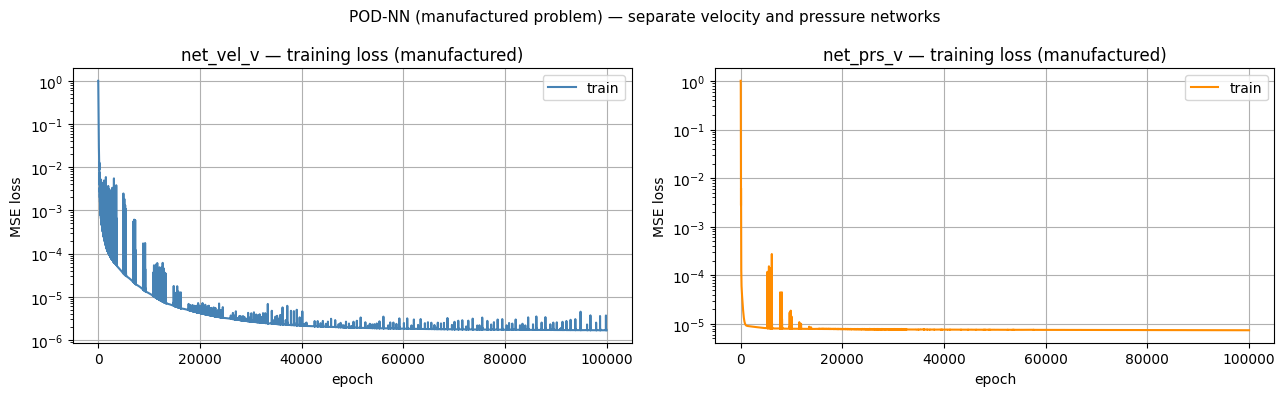

In [50]:
torch.manual_seed(42)

class PODNN_Val(nn.Module):
    def __init__(self, out_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(mu_dim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, out_dim)
        )
    def forward(self, x):
        return self.net(x)

net_vel_v = PODNN_Val(out_dim=N_u_v)
net_prs_v = PODNN_Val(out_dim=N_p_v)

print(f"net_vel_v output: {N_u_v}  (pure velocity POD, supremizers dropped)")

loss_fn_v  = nn.MSELoss()
opt_vel_v  = torch.optim.Adam(net_vel_v.parameters(), lr=1e-3)
opt_prs_v  = torch.optim.Adam(net_prs_v.parameters(), lr=1e-3)

sched_vel_v = lr_scheduler.ReduceLROnPlateau(opt_vel_v, mode='min',
                                              factor=0.5, patience=500, min_lr=1e-6)
sched_prs_v = lr_scheduler.ReduceLROnPlateau(opt_prs_v, mode='min',
                                              factor=0.5, patience=500, min_lr=1e-6)

epoch_max_val   = 100_000
es_patience_v   = 3_000
es_min_epoch_v  = 10_000   
smooth_window_v = 200      

best_train_vel_v = float('inf')
best_train_prs_v = float('inf')
best_wts_vel_v   = copy.deepcopy(net_vel_v.state_dict())
best_wts_prs_v   = copy.deepcopy(net_prs_v.state_dict())
no_impr_vel_v    = 0
no_impr_prs_v    = 0
stopped_vel_v    = False
stopped_prs_v    = False

hist_vel_v, hist_prs_v = [], []
epoch_v = 0

print("Training net_vel_v and net_prs_v (manufactured problem, train-loss early stopping)...")

while epoch_v < epoch_max_val and not (stopped_vel_v and stopped_prs_v):
    epoch_v += 1

    # ── velocity ──────────────────────────────────────────────────────────────
    if not stopped_vel_v:
        net_vel_v.train()
        opt_vel_v.zero_grad()
        lv_vel_ = loss_fn_v(net_vel_v(x_train_val), y_train_vel_val)
        lv_vel_.backward(); opt_vel_v.step()

        hist_vel_v.append(lv_vel_.item())

        smooth_vel_v = float(np.mean(hist_vel_v[-smooth_window_v:]))
        sched_vel_v.step(smooth_vel_v)

        if epoch_v >= es_min_epoch_v:
            if smooth_vel_v < best_train_vel_v:
                best_train_vel_v = smooth_vel_v
                best_wts_vel_v = copy.deepcopy(net_vel_v.state_dict())
                no_impr_vel_v  = 0
            else:
                no_impr_vel_v += 1
                if no_impr_vel_v >= es_patience_v:
                    stopped_vel_v = True
                    net_vel_v.load_state_dict(best_wts_vel_v)
                    print(f"  [epoch {epoch_v}] net_vel_v early stopped — "
                          f"best smoothed train loss {best_train_vel_v:.4e}")

    # ── pressure ──────────────────────────────────────────────────────────────
    if not stopped_prs_v:
        net_prs_v.train()
        opt_prs_v.zero_grad()
        lv_prs_ = loss_fn_v(net_prs_v(x_train_val), y_train_prs_val)
        lv_prs_.backward(); opt_prs_v.step()

        hist_prs_v.append(lv_prs_.item())

        smooth_prs_v = float(np.mean(hist_prs_v[-smooth_window_v:]))
        sched_prs_v.step(smooth_prs_v)

        if epoch_v >= es_min_epoch_v:
            if smooth_prs_v < best_train_prs_v:
                best_train_prs_v = smooth_prs_v
                best_wts_prs_v = copy.deepcopy(net_prs_v.state_dict())
                no_impr_prs_v  = 0
            else:
                no_impr_prs_v += 1
                if no_impr_prs_v >= es_patience_v:                    
                    stopped_prs_v = True
                    net_prs_v.load_state_dict(best_wts_prs_v)
                    print(f"  [epoch {epoch_v}] net_prs_v early stopped — "
                          f"best smoothed train loss {best_train_prs_v:.4e}")

    if epoch_v % 5_000 == 0:
        lr_now_v = opt_vel_v.param_groups[0]['lr']
        lr_now_p = opt_prs_v.param_groups[0]['lr']
        sv = float(np.mean(hist_vel_v[-smooth_window_v:])) if hist_vel_v else float('nan')
        sp = float(np.mean(hist_prs_v[-smooth_window_v:])) if hist_prs_v else float('nan')
        print(f"  epoch {epoch_v:>7d} | "
              f"vel: smooth-train {sv:.4e} (lr: {lr_now_v:.1e}) | "
              f"prs: smooth-train {sp:.4e} (lr: {lr_now_p:.1e})")

net_vel_v.load_state_dict(best_wts_vel_v)
net_prs_v.load_state_dict(best_wts_prs_v)

print(f"\nFinished at epoch {epoch_v}")
print(f"  best smoothed train_vel = {best_train_vel_v:.4e}   "
      f"best smoothed train_prs = {best_train_prs_v:.4e}")

# ── Loss curves ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].semilogy(hist_vel_v, color='steelblue', label='train')
axes[0].set_title('net_vel_v — training loss (manufactured)')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('MSE loss')
axes[0].legend(); axes[0].grid(True)

axes[1].semilogy(hist_prs_v, color='darkorange', label='train')
axes[1].set_title('net_prs_v — training loss (manufactured)')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('MSE loss')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('POD-NN (manufactured problem) — separate velocity and pressure networks', fontsize=11)
plt.tight_layout()
plt.show()


### 8.4 — Error vs exact solution: POD-NN, FOM, and POD-ROM compared

For each test parameter we compute **three** L2 errors against the true $(u,v,p)$:
- **FOM error**: discretisation error only
- **POD-ROM error**: best approximation error in $V_N$ (lower bound for both ROM and NN)
- **POD-NN error**: our full pipeline error

The POD-NN error should stay close to the FOM and POD-ROM errors.

In [51]:
def l2_error_vs_exact(u_num, u_strong, dofs_data, ref_elem, exact_fn, label):
    """Return absolute L2 error and L2 norm of the numerical solution against exact_fn."""
    res = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
        geometry_utilities, mesh, mesh_geometric_data,
        dofs_data, ref_elem, u_num, u_strong, exact_fn)
    return res.error_l2, res.numeric_norm_l2


np.random.seed(99)
P_interior_v = np.array([[0.5, 9.5], [1.2, 2.8]])
testing_set_val = np.random.uniform(low=P_interior_v[:, 0], high=P_interior_v[:, 1],
                                    size=(30, P.shape[0]))

zero_strong_u = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
    geometry_utilities, mesh, mesh_geometric_data,
    speed_mesh_dofs_info, speed_dofs_data, speed_reference_element_data,
    speed_x_strong_function)   # = 0 everywhere
zero_strong_p = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
    geometry_utilities, mesh, mesh_geometric_data,
    pressure_mesh_dofs_info, pressure_dofs_data, pressure_reference_element_data,
    pressure_strong_function)

results_val = []
speed_up_nn_val = []
net_vel_v.eval(); net_prs_v.eval()

print("Computing errors vs exact solution (interior test points)...")
print(f"{'mu0':>6} {'mu1':>6} | {'FOM ux':>10} {'FOM uy':>10} {'FOM p':>10} "
      f"| {'NN ux':>10} {'NN uy':>10} {'NN p':>10} | {'SpeedUp':>8}")
print('-' * 96)

for mu in testing_set_val:
    # ── FOM (timed) ───────────────────────────────────────────────────────────
    start_fom = time.time()
    fom_k   = solve_ns_manuf(mu)
    time_fom = time.time() - start_fom

    fom_ux  = fom_k[0:speed_n_dofs]
    fom_uy  = fom_k[speed_n_dofs:2*speed_n_dofs]
    fom_p   = fom_k[2*speed_n_dofs:]

    e_fom_ux, _ = l2_error_vs_exact(fom_ux, zero_strong_u, speed_dofs_data,
                                     speed_reference_element_data, ux_exact_fn, 'ux')
    e_fom_uy, _ = l2_error_vs_exact(fom_uy, zero_strong_u, speed_dofs_data,
                                     speed_reference_element_data, uy_exact_fn, 'uy')
    e_fom_p,  _ = l2_error_vs_exact(fom_p,  zero_strong_p, pressure_dofs_data,
                                     pressure_reference_element_data, p_exact_fn, 'p')

    # ── POD-NN (timed) ────────────────────────────────────────────────────────
    mu_n = 2.0 * (np.float32(mu) - mu_min) / (mu_max - mu_min) - 1.0
    x_t  = torch.tensor(mu_n[None, :])

    start_nn = time.time()
    with torch.no_grad():
        cv_n = net_vel_v(x_t).numpy()[0]
        cp_n = net_prs_v(x_t).numpy()[0]
    cv     = cv_n * vel_v_std + vel_v_mean
    cp     = cp_n * prs_v_std + prs_v_mean
    nn_vel = B_vel_v @ cv  
    nn_prs = B_prs_v @ cp   
    time_nn = time.time() - start_nn

    nn_FE  = np.concatenate([nn_vel, nn_prs])
    nn_ux  = nn_FE[0:speed_n_dofs]
    nn_uy  = nn_FE[speed_n_dofs:2*speed_n_dofs]
    nn_p   = nn_FE[2*speed_n_dofs:]

    e_nn_ux, _ = l2_error_vs_exact(nn_ux, zero_strong_u, speed_dofs_data,
                                    speed_reference_element_data, ux_exact_fn, 'ux')
    e_nn_uy, _ = l2_error_vs_exact(nn_uy, zero_strong_u, speed_dofs_data,
                                    speed_reference_element_data, uy_exact_fn, 'uy')
    e_nn_p,  _ = l2_error_vs_exact(nn_p,  zero_strong_p, pressure_dofs_data,
                                    pressure_reference_element_data, p_exact_fn, 'p')

    su = time_fom / time_nn
    speed_up_nn_val.append(su)

    results_val.append(dict(
        mu0=mu[0], mu1=mu[1],
        e_fom_ux=e_fom_ux, e_fom_uy=e_fom_uy, e_fom_p=e_fom_p,
        e_nn_ux=e_nn_ux,   e_nn_uy=e_nn_uy,   e_nn_p=e_nn_p,
        time_fom=time_fom, time_nn=time_nn,    speed_up=su
    ))
    print(f"{mu[0]:6.3f} {mu[1]:6.3f} | "
          f"{e_fom_ux:10.3e} {e_fom_uy:10.3e} {e_fom_p:10.3e} | "
          f"{e_nn_ux:10.3e} {e_nn_uy:10.3e} {e_nn_p:10.3e} | "
          f"{su:8.1f}x")


Computing errors vs exact solution (interior test points)...
   mu0    mu1 |     FOM ux     FOM uy      FOM p |      NN ux      NN uy       NN p |  SpeedUp
------------------------------------------------------------------------------------------------
 6.551  1.981 |  1.044e-04  1.012e-04  2.929e-02 |  1.044e-04  1.012e-04  2.929e-02 |   1151.1x
 7.929  1.250 |  1.042e-04  1.011e-04  3.274e-02 |  1.042e-04  1.011e-04  3.274e-02 |   2368.3x
 7.772  2.105 |  1.042e-04  1.011e-04  3.234e-02 |  1.042e-04  1.011e-04  3.234e-02 |   2053.4x
 3.179  1.275 |  1.064e-04  1.025e-04  2.178e-02 |  1.064e-04  1.025e-04  2.179e-02 |   1945.2x
 9.416  1.211 |  1.040e-04  1.011e-04  3.660e-02 |  1.040e-04  1.011e-04  3.660e-02 |   2027.8x
 7.428  2.395 |  1.043e-04  1.012e-04  3.147e-02 |  1.043e-04  1.012e-04  3.147e-02 |   2215.3x
 3.897  1.991 |  1.056e-04  1.019e-04  2.323e-02 |  1.056e-04  1.019e-04  2.323e-02 |   2288.1x
 8.861  1.833 |  1.041e-04  1.011e-04  3.515e-02 |  1.041e-04  1.011e-04  3

In [52]:
n = len(results_val)

if n == 0:
    print("No results to calculate statistics for.")
else:
    # Calculate means for FOM
    mean_e_fom_ux = sum(r['e_fom_ux'] for r in results_val) / n
    mean_e_fom_uy = sum(r['e_fom_uy'] for r in results_val) / n
    mean_e_fom_p  = sum(r['e_fom_p'] for r in results_val) / n

    # Calculate means for POD-NN
    mean_e_nn_ux = sum(r['e_nn_ux'] for r in results_val) / n
    mean_e_nn_uy = sum(r['e_nn_uy'] for r in results_val) / n
    mean_e_nn_p  = sum(r['e_nn_p'] for r in results_val) / n

    # Calculate mean overheads (the mean of the element-wise ratios)
    mean_over_ux = sum(r['e_nn_ux'] / r['e_fom_ux'] for r in results_val) / n
    mean_over_uy = sum(r['e_nn_uy'] / r['e_fom_uy'] for r in results_val) / n
    mean_over_p  = sum(r['e_nn_p'] / r['e_fom_p'] for r in results_val) / n

    # Speed-up statistics for the manufactured (known-solution) problem
    mean_su  = sum(r['speed_up'] for r in results_val) / n
    min_su   = min(r['speed_up'] for r in results_val)
    max_su   = max(r['speed_up'] for r in results_val)
    mean_t_fom = sum(r['time_fom'] for r in results_val) / n
    mean_t_nn  = sum(r['time_nn']  for r in results_val) / n

    print("\n=== Mean L2 errors vs exact solution ===")
    print(f"{'':30s} {'u_x':>12} {'u_y':>12} {'p':>12}")
    print(f"{'FOM (discretisation floor)':30s}"
          f" {mean_e_fom_ux:12.3e} {mean_e_fom_uy:12.3e} {mean_e_fom_p:12.3e}")
    print(f"{'POD-NN (full pipeline)':30s}"
          f" {mean_e_nn_ux:12.3e}  {mean_e_nn_uy:12.3e}  {mean_e_nn_p:12.3e}")
    print(f"{'NN / FOM overhead':30s}"
          f" {mean_over_ux:12.2f}x {mean_over_uy:12.2f}x {mean_over_p:12.2f}x")

    print("\n=== Speed-up (manufactured / known-solution problem) ===")
    print(f"  Mean FOM wall-time  : {mean_t_fom:.4f} s")
    print(f"  Mean NN  wall-time  : {mean_t_nn:.6f} s")
    print(f"  Speed-up  — mean    : {mean_su:.1f}x")
    print(f"             min/max  : {min_su:.1f}x / {max_su:.1f}x")



=== Mean L2 errors vs exact solution ===
                                        u_x          u_y            p
FOM (discretisation floor)        1.059e-04    1.023e-04    2.717e-02
POD-NN (full pipeline)            1.059e-04     1.023e-04     2.717e-02
NN / FOM overhead                      1.00x         1.00x         1.00x

=== Speed-up (manufactured / known-solution problem) ===
  Mean FOM wall-time  : 1.0597 s
  Mean NN  wall-time  : 0.000502 s
  Speed-up  — mean    : 2153.6x
             min/max  : 1151.1x / 2555.8x


Demo point: mu0=1.343, mu1=2.501
POD-NN  u_x:


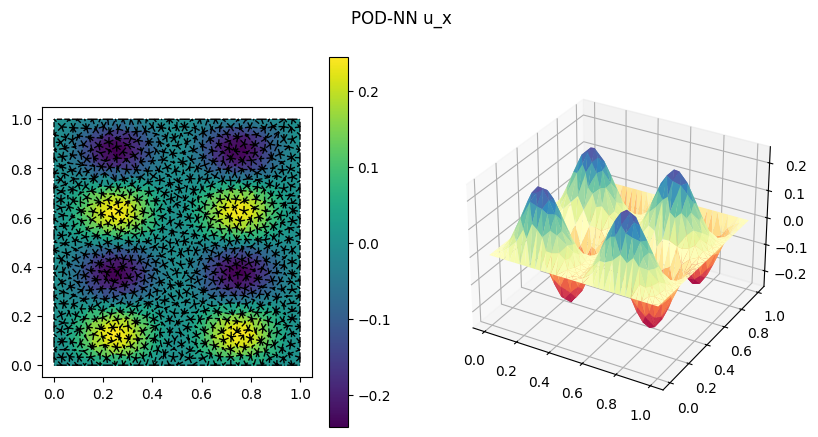

POD-NN  u_y:


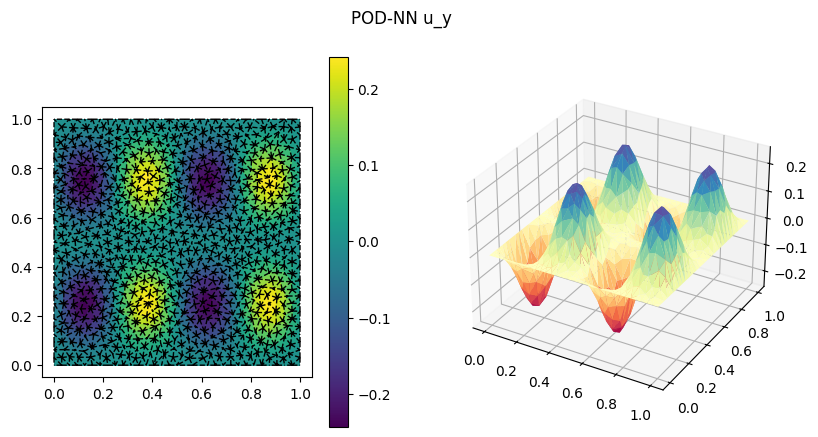

POD-NN  p (manufactured exact-solution problem):


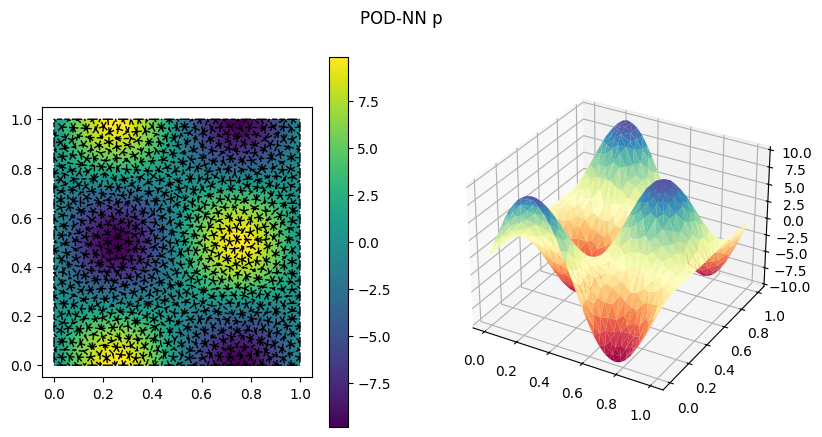

In [53]:
idx_closest = min(range(len(results_val)), key=lambda i: abs(results_val[i]['mu0'] - 1.0))
mu_demo = testing_set_val[idx_closest]  # mu0 closest to 1

print(f"Demo point: mu0={mu_demo[0]:.3f}, mu1={mu_demo[1]:.3f}")

mu_demo_n = 2.0 * (np.float32(mu_demo) - mu_min) / (mu_max - mu_min) - 1.0
x_demo = torch.tensor(mu_demo_n[None, :])

with torch.no_grad():
    cv_d = net_vel_v(x_demo).numpy()[0]
    cp_d = net_prs_v(x_demo).numpy()[0]

cv_demo = cv_d * vel_v_std + vel_v_mean
cp_demo = cp_d * prs_v_std + prs_v_mean
nn_demo = np.concatenate([B_vel_v @ cv_demo, B_prs_v @ cp_demo])
nn_ux_d = nn_demo[0:speed_n_dofs]
nn_uy_d = nn_demo[speed_n_dofs:2*speed_n_dofs]
nn_p_d  = nn_demo[2*speed_n_dofs:]

# Extract cell values for velocity.
nn_ux_cell = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(
    mesh, speed_dofs_data, nn_ux_d, zero_strong_u)
nn_uy_cell = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(
    mesh, speed_dofs_data, nn_uy_d, zero_strong_u)
# Extract cell values for pressure.
nn_p_cell  = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(
    mesh, pressure_dofs_data, nn_p_d, zero_strong_p)

print("POD-NN  u_x:")
other_ut.plot_solution(mesh, nn_ux_cell.numeric_solution, "POD-NN u_x")
print("POD-NN  u_y:")
other_ut.plot_solution(mesh, nn_uy_cell.numeric_solution, "POD-NN u_y")
print("POD-NN  p (manufactured exact-solution problem):")
other_ut.plot_solution(mesh, nn_p_cell.numeric_solution, "POD-NN p")
